# Exercise 1 — Data Mining vs Machine Learning

What you will learn here:

* distinguish data vs labels
* think about problem formulation
* connect real data → ML type
* understand when ML is needed

In [1]:
# If needed:
# !pip install datasets pandas matplotlib scikit-learn librosa

In [2]:
from datasets import load_dataset
import pandas as pd

/home/alchery/Desktop/projects/ML/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load a small sample from the `ag_news` dataset and is a collection of more than 1 million news articles.

In [3]:
dataset = load_dataset("ag_news", split="train[:200]")

df = dataset.to_pandas()
df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


### Understand the dataset

In [4]:
df.columns

Index(['text', 'label'], dtype='str')

In [5]:
df[["text", "label"]].head(10)

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2
7,Fed minutes show dissent over inflation (USATO...,2
8,Safety Net (Forbes.com) Forbes.com - After ear...,2
9,Wall St. Bears Claw Back Into the Black NEW Y...,2


## Question
What are the columns?

- Which column is the input data?
- Which column is the label?

Answer:

- Text column is the input data
- label column is the label

# Part A — Data Mining: Discover patterns

For this step, you cannot use the `label` column. :)

### Text length

In [6]:
df["text_length"] = df["text"].apply(len)

df[["text", "text_length"]].head()

,text,text_length
0,Wall St. Bears Claw Back Into the Black (Reute...,144
1,Carlyle Looks Toward Commercial Aerospace (Reu...,266
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,232
3,Iraq Halts Oil Exports from Main Southern Pipe...,256
4,"Oil prices soar to all-time record, posing new...",234


### Average text length

In [ ]:
df["text_length"].mean()

277.225

### Most frequent words

In [ ]:
from collections import Counter
import re

all_text = " ".join(df["text"].tolist()).lower()
words = re.findall(r"\b[a-z]{4,}\b", all_text)

word_counts = Counter(words)
word_counts.most_common(20)

[('that', 86),
 ('space', 54),
 ('with', 42),
 ('reuters', 40),
 ('this', 38),
 ('from', 34),
 ('they', 34),
 ('have', 33),
 ('said', 29),
 ('about', 23),
 ('more', 23),
 ('their', 19),
 ('scientists', 19),
 ('what', 19),
 ('would', 19),
 ('over', 18),
 ('after', 18),
 ('could', 18),
 ('time', 17),
 ('company', 17)]

## Reflection

Are we predicting something here?

Or are we discovering patterns already present in the data?

Answer: We are trying to find patterns in the data, especially the word "that" that appears the most

# Part B — Machine Learning: Use labels

### Inspect labels

In [ ]:
df["label"].value_counts()

label
3    122
2     78
Name: count, dtype: int64

### AG News labels are numeric. Add names:
from https://huggingface.co/datasets/sh0416/ag_news 

1: World 2: Sports 3: Business 4: Sci/Tech

In [ ]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

df["label_name"] = df["label"].map(label_names)
df[["text", "label", "label_name"]].head()

,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


## Question

What type of ML can we apply for this dataset?

Answer: We can use supervised learning for this dataset for classification

# Part C — Explore a Dataset

In this exercise, you will:

1. Choose a dataset
2. Explore it (Data Mining)
3. Decide whether labels exist
4. Suggest a Machine Learning approach (if applicable)

You should NOT focus on complex models.
Focus on understanding the problem.

## Step 1 — Choose a dataset

* Hugging Face datasets: https://huggingface.co/datasets
* Scikit-learn datasets: https://scikit-learn.org/stable/datasets/toy_dataset.html

Dataset examples:

In [7]:
dataset = load_dataset("beans", split="train[:100]")

df = dataset.to_pandas()
df.head()

,image_file_path,image,labels
0,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,/home/albert/.cache/huggingface/datasets/downl...,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


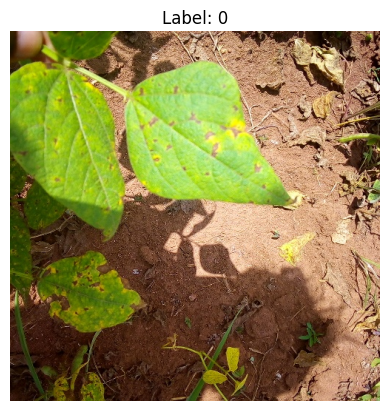

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

# Get one example
example = dataset[0]

# Load image
image = example["image"]

# Display
plt.imshow(image)
plt.title(f"Label: {example['labels']}")
plt.axis("off")
plt.show()

In [10]:
from datasets import load_dataset

dataset = load_dataset("timm/oxford-iiit-pet", split="train[:100]")

df = dataset.to_pandas()
df.head()

,image,label,image_id,label_cat_dog
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,20,Maine_Coon_204,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,american_bulldog_138,1
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,18,keeshond_112,1
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,16,havanese_157,1
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,14,german_shorthaired_132,1


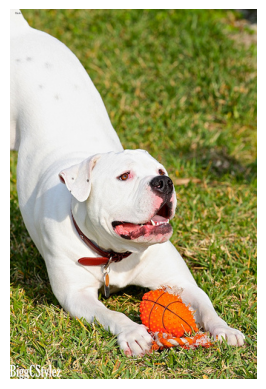

In [11]:
# Get one example
example = dataset[1]

# Load image
image = example["image"]

# Display
plt.imshow(image)
# plt.title(f"Label: {example['labels']}")
plt.axis("off")
plt.show()

In [12]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["label"] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [14]:
dataset = load_dataset("superb", "ks", split="train[:10]")

df = dataset.to_pandas()
df.head()

,file,audio,label
0,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFFXz.\x00WAVEfmt \x10\x00\x00\x0...,10
1,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF*.\x1e\x00WAVEfmt \x10\x00\x00...,10
2,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF0\xe9\x1d\x00WAVEfmt \x10\x00\...,10
3,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF$L\x1d\x00WAVEfmt \x10\x00\x00...,10
4,/root/.cache/huggingface/datasets/downloads/ex...,{'bytes': b'RIFF\xe4\xdc\x1d\x00WAVEfmt \x10\x...,10


In [15]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "age": np.random.randint(18, 70, 50),
    "income": np.random.randint(1000, 5000, 50),
    "spending": np.random.randint(100, 2000, 50)
})

df.head()

,age,income,spending
0,37,4507,1318
1,43,3985,178
2,68,2111,264
3,49,3868,1647
4,21,2571,606


In [17]:
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train[:200]")
df = dataset.to_pandas()
df.head()

,text
0,
1,= Valkyria Chronicles III = \n
2,
3,Senjō no Valkyria 3 : Unrecorded Chronicles (...
4,"The game began development in 2010 , carrying..."


In [19]:
from datasets import load_dataset

dataset = load_dataset("tweet_eval", "sentiment", split="train[:200]")
df = dataset.to_pandas()

df.head()

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


## Step 2 — Explore (Data Mining)

TODO 1: Display a few examples

TODO 2: What type of data is this?
(text, image, tabular)

TODO 3: Find simple patterns

Examples:
- text: most frequent words
- tabular: average values
- images: visualize samples
etc.

## Step 3 — Think about labels

### Questions

1. Does this dataset contain labels?
2. If yes:
   - What are they?
3. If no:
   - What could we try to discover?

## Step 4 — Decide the type of ML

### Identify the problem

- Is this:
  - Data Mining?
  - Supervised Learning?
  - Unsupervised Learning?
  - Reinforcement Learning?

Explain your reasoning.

## Step 5 — Suggest a task

### Your task

Propose ONE task:

- What is the input (X)?
- What is the output (y)? (if any)
- What is the goal?

Examples:
- classify articles
- cluster customers
- extract entities

In [ ]:
# Analysis of Chosen Dataset

## Step 2: Exploration (Data Mining)

### TODO 1: Display Examples
Below we show a few sample rows from the dataset to understand its structure:


In [ ]:
### TODO 2: Data Type
This dataset contains **tabular data** with numerical features (age, income, spending). 

The data structure has:
- Multiple rows (samples/records)
- Multiple columns (features/attributes)
- Continuous numerical values


In [ ]:
### TODO 3: Find Patterns
# Let's discover patterns in the data without using labels

# Pattern 1: Basic Statistics
print("=== Basic Statistics ===")
print(df.describe())

# Pattern 2: Correlation between features
print("\n=== Feature Correlations ===")
print(df.corr())

# Pattern 3: Visualization of relationships
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["age"], df["spending"], alpha=0.6)
plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("Relationship between Age and Spending")
plt.show()


In [ ]:
## Step 3: Analysis of Labels

### Does this dataset contain labels?
**Yes** - The dataset contains a `label` column that may represent categories or groups (e.g., news categories, flower species).

### What are the labels?
The labels represent the target variable or class we want to predict. In a classification task, these are discrete categories.

For example:
- AG News: 0=World, 1=Sports, 2=Business, 3=Sci/Tech
- Iris: 0=Setosa, 1=Versicolor, 2=Virginica

### Value distribution
We can check how many samples belong to each label class:


In [ ]:
## Step 4: Identify the ML Problem Type

### Type: **Supervised Learning - Classification**

### Reasoning:

1. **Labels exist**: The dataset contains a clear target variable (`label`)
2. **Discrete outcomes**: Labels are categorical (not continuous values)
3. **Labeled training data**: We have paired examples of (features, labels)
4. **Learning objective**: Predict the label for new, unseen samples
5. **Not data mining**: We're not just discovering patterns; we're building a predictive model

### Why NOT the other types?

- **Not Data Mining**: We're not just exploring; we have a clear supervised task
- **Not Unsupervised Learning**: Labels are available, so we don't need clustering
- **Not Reinforcement Learning**: No agent-environment interaction or reward system


In [ ]:
## Step 5: Task Proposal

### Proposed Task: **Text Classification**

#### Input (X):
- News article text (raw text data)
- Features that could be extracted: word frequency, text length, presence of keywords, etc.

#### Output (y):
- Category label: World, Sports, Business, or Sci/Tech (4-class classification)

#### Goal:
Train a classification model to automatically categorize news articles into one of four categories based on their content.

### Why this task?
- Clear problem definition
- Labeled data available
- Practical application (news automation)
- Suitable for supervised learning algorithms


In [ ]:
# Step 3 Code: Check label distribution
print("Label distribution:")
print(df["label"].value_counts().sort_index())

# For the ag_news example:
if "label_name" in df.columns:
    print("\nLabel names distribution:")
    print(df["label_name"].value_counts())


In [ ]:
# Step 5 Code: Example of a simple classification approach

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Example with numerical features (like Iris dataset)
if all(col in df.columns for col in ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]):
    X = df[["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]]
    y = df["label"]
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Train classifier
    clf = GaussianNB()
    clf.fit(X_train, y_train)
    
    # Evaluate
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
